In [1]:
import requests
import os
import ahttp
import pandas as pd
from astropy.io import ascii
import numpy as np
from astropy.table import Table
import sys


def get_by_position(ra, dec, radius=2.5):
    ALLWISE_cat = 'allwise_p3as_mep'                                                                                                                                                        
    NEOWISE_cat = 'neowiser_p1bs_psd'
    query_url = 'http://irsa.ipac.caltech.edu/cgi-bin/Gator/nph-query'
    payload = {
        'catalog': ALLWISE_cat,
        'spatial': 'cone',
        'objstr': ' '.join([str(ra), str(dec)]),
        'radius': str(radius),
        'radunits': 'arcsec',
        'outfmt': '1'
    }
    r = requests.get(query_url, params=payload)
    allwise = ascii.read(r.text)
    payload = {
        'catalog': NEOWISE_cat,
        'spatial': 'cone',
        'objstr': ' '.join([str(ra), str(dec)]),
        'radius': str(radius),
        'radunits': 'arcsec',
        'outfmt': '1',
        'selcols': 'ra,dec,sigra,sigdec,sigradec,glon,glat,elon,elat,w1mpro,w1sigmpro,w1snr,w1rchi2,w2mpro,w2sigmpro,w2snr,w2rchi2,rchi2,nb,na,w1sat,w2sat,satnum,cc_flags,det_bit,ph_qual,sso_flg,qual_frame,qi_fact,saa_sep,moon_masked,w1frtr,w2frtr,mjd,allwise_cntr,r_allwise,pa_allwise,n_allwise,w1mpro_allwise,w1sigmpro_allwise,w2mpro_allwise,w2sigmpro_allwise,w3mpro_allwise,w3sigmpro_allwise,w4mpro_allwise,w4sigmpro_allwise'
    }
    
    r = requests.get(query_url, params=payload)

    neowise = ascii.read(r.text, guess=False, format='ipac')

    return allwise, neowise

    
def download_single_data(name, ra, dec, root_path='./ipac/', radius=2.5):
    # ra, dec: in degree
    # name, ra, dec = row['Name'], row['RAJ2000'], row['DEJ2000']
    # name = 'J' + ra + dec
    if root_path[-1] != '/':
        root_path += '/'
    if os.path.isfile(root_path + name +str(ra)[0:10]+'_'+str(dec)[0:10]+ '_allwise.ipac') and os.path.isfile(root_path + name +str(ra)[0:10]+'_'+str(dec)[0:10]+ '_neowise.ipac'):
        pass
    else:
        allwise, neowise = get_by_position(ra, dec, radius=radius)
        allwise.write(root_path + name +str(ra)[0:10]+'_'+str(dec)[0:10]+ '_allwise.ipac', format='ascii.ipac', overwrite=True)
        neowise.write(root_path + name + str(ra)[0:10]+'_'+str(dec)[0:10]+'_neowise.ipac', format='ascii.ipac', overwrite=True)



In [2]:
from astropy import units as u
from astropy.coordinates import SkyCoord
c = SkyCoord('02h12m18.62s', '00d44m56.50s', frame='icrs')
c

<SkyCoord (ICRS): (ra, dec) in deg
    (33.07758333, 0.74902778)>

In [2]:
def get_data_arrays(table, t, mag, magerr):
    """Get the time series from a potentially masked astropy table"""
    if table.masked:
        full_mask = table[t].mask | table[mag].mask | table[magerr].mask
        t = table[t].data
        mag = table[mag].data
        magerr = table[magerr].data

        t.mask = full_mask
        mag.mask = full_mask
        magerr.mask = full_mask

        return t.compressed(), mag.compressed(), magerr.compressed()

    else:
        return table[t].data, table[mag].data, table[magerr].data

def make_full_lightcurve(allwise, neowise, band):
    """band = 'w1', 'w2', 'w3', or 'w4' """
    """Get a combined AllWISE and NEOWISE lightcurve from their Astropy tables"""

    if band not in ['w1', 'w2', 'w3', 'w4']:
        raise ValueError('band can only be w1, w2, w3, or w4')

    t, m, e = get_data_arrays(allwise, 'mjd', band + 'mpro_ep', band + 'sigmpro_ep')
    if band in ['w1', 'w2']:
        t_n, m_n, e_n = get_data_arrays(neowise, 'mjd', band + 'mpro', band + 'sigmpro')
        t, m, e = np.concatenate((t, t_n)), np.concatenate((m, m_n)), np.concatenate((e, e_n))

    t_index = t.argsort()
    t, m, e = map(lambda e: e[t_index], [t, m, e])
    return t, m, e

def cntr_to_source_id(cntr):
    cntr = str(cntr)

    # fill leanding 0s
    if len(cntr) < 19:
        num_leading_zeros = 19 - len(cntr)
        cntr = '0' * num_leading_zeros + cntr

    pm = 'p'
    if cntr[4] == '0':
        pm = 'm'

    t = chr(96 + int(cntr[8:10]))

    # return '%04d%s%03d_%sc%02d-%06d' %(cntr[0:4], pm, cntr[5:8], t, cntr[11:13], cntr[13:19])
    return '%s%s%s_%cc%s-%s' % (cntr[0:4], pm, cntr[5:8], t, cntr[11:13], cntr[13:19])

def only_good_data_v1(allwise, neowise):
    """
    Select good-quality data. The criteria include:
    - matching the all-wise ID

    To be done:
    - deal with multiple cntr
    """

    cntr_list = []
    for data in neowise:
        # print data['allwise_cntr']
        if data['allwise_cntr'] not in cntr_list and data['allwise_cntr'] > 10.:
            cntr_list.append(data['allwise_cntr'])

    if len(cntr_list) >= 2:
        print('multiple cntr:')
        print(cntr_list)
        return 0, 0

    if len(cntr_list) == 0:
        print('no cntr')
        return 0, 0

    cntr = cntr_list[0]

    source_id = cntr_to_source_id(cntr)

    allwise = allwise[
        (allwise['source_id_mf'] == source_id) *
        (allwise['saa_sep'] > 0.) *
        (allwise['moon_masked'] == '0000') *
        (allwise['qi_fact'] > 0.9)
        ]

    # old version
    # neowise = neowise[
    #    (neowise['qual_frame'] > 0.)
    # ]

    # new version
    neowise = neowise[
        (neowise['qual_frame'] > 0.) *
        (neowise['qi_fact'] > 0.9) *
        (neowise['saa_sep'] > 0) *
        (neowise['moon_masked'] == '00')
        ]

    return allwise, neowise

def make_full_lightcurve_multibands(allwise, neowise, bands=['w1', 'w2']):
    t, m, e = make_full_lightcurve(allwise, neowise, bands[0])
    filts = [bands[0] for i in range(len(t))]
    for band in bands[1:]:
        t_tmp, m_tmp, e_tmp = make_full_lightcurve(allwise, neowise, band)
        t = np.concatenate((t, t_tmp))
        m = np.concatenate((m, m_tmp))
        e = np.concatenate((e, e_tmp))
        filts += [band for i in range(len(t_tmp))]
    return t, m, e, np.array(filts)


In [3]:
import matplotlib.pyplot as plt

def neowise_viewer_show(path, ra, dec):
    ra_str = str(ra)[0:10]
    dec_str = str(dec)[0:10]
    allwise = ascii.read(path + '%s_%s_allwise.ipac'%(ra_str,dec_str), format='ipac')
    neowise = ascii.read(path + '%s_%s_neowise.ipac'%(ra_str,dec_str), format='ipac')
    # allwise, neowise = only_good_data_v1(allwise, neowise)
    t, mag, mag_err, filts = make_full_lightcurve_multibands(allwise, neowise)
    t_w1 = t[filts == 'w1']
    t_w2 = t[filts == 'w2']
    mag_w1 = mag[filts == 'w1']
    mag_w2 = mag[filts == 'w2']
    mag_err_w1 = mag_err[filts == 'w1']
    mag_err_w2 = mag_err[filts == 'w2']

    plt.errorbar(t_w1,mag_w1,mag_err_w1, fmt='o',ms=4, mfc='r', elinewidth=1, capsize=2)
    plt.title('w1')
    plt.show()
    
    plt.errorbar(t_w2,mag_w2,mag_err_w2, fmt='o',ms=4, mfc='r', elinewidth=1, capsize=2)
    plt.title('w2')
    plt.show()

In [10]:
ra = 42.8668825
dec = -39.0860425
download_single_data(name='IR_extreme_luminious_', ra=ra, dec=dec,
            root_path='./ipac/', radius=5)

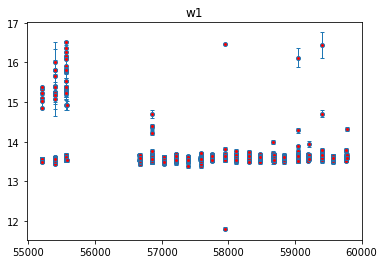

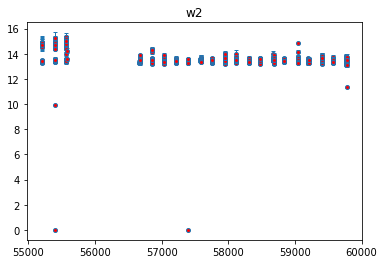

In [11]:
g
neowise_viewer_show('./ipac/IR_extreme_luminious_', ra, dec)